# Data Quality Analysis
Используем датасет, собранный в первом задании (IMDB). Анализируем качество данных и применяем стратегии очистки.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from data_quality_agent import DataQualityAgent

# Загружаем последний CSV из папки data/raw (скопируйте туда файл из первого задания)
files = sorted(glob.glob("../data/raw/*.csv"))
if not files:
    print("Нет файлов в data/raw/. Пожалуйста, скопируйте CSV из первого задания.")
else:
    latest = files[-1]
    df = pd.read_csv(latest)
    print(f"Загружен файл: {latest}")
    print(f"Размер: {df.shape}")
    df.head()

Загружен файл: ../data/raw\collected_20260324_143508.csv
Размер: (25000, 4)


In [2]:
# Добавим числовую колонку для демонстрации выбросов (длина текста)
if 'content' in df.columns:
    df['text_length'] = df['content'].astype(str).apply(len)
    print("Добавлена колонка 'text_length' для анализа выбросов.")

Добавлена колонка 'text_length' для анализа выбросов.


In [3]:
agent = DataQualityAgent()
report = agent.detect_issues(df)
print("Пропущенные значения:", report['missing'])
print("Дубликаты:", report['duplicates'])
print("Выбросы (по колонкам):", report['outliers'])
print("Дисбаланс классов:", report['imbalance'])

Пропущенные значения: {}
Дубликаты: 96
Выбросы (по колонкам): {'text_length': 1840}
Дисбаланс классов: {'0': {'count': 12500, 'ratio': 0.5}, '1': {'count': 12500, 'ratio': 0.5}}


## Визуализация проблем

In [4]:
# Пропуски
if report['missing']:
    plt.figure(figsize=(10,4))
    missing_counts = pd.Series(report['missing'])
    missing_counts.plot(kind='bar')
    plt.title('Пропущенные значения по колонкам')
    plt.ylabel('Количество')
    plt.show()
else:
    print('Нет пропусков')

Нет пропусков


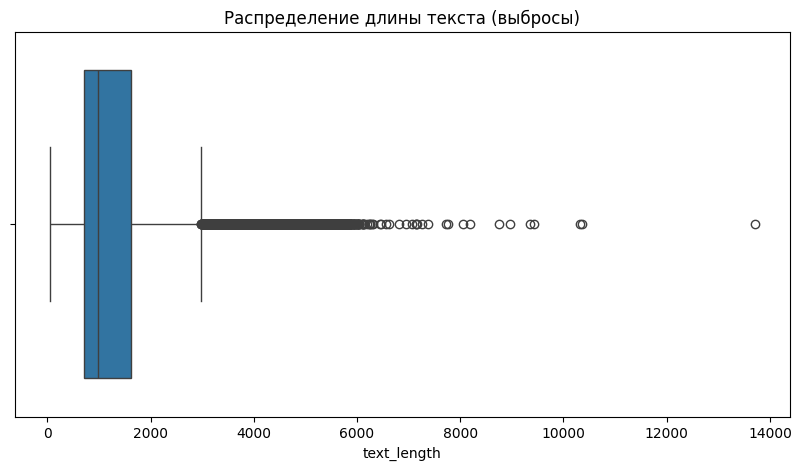

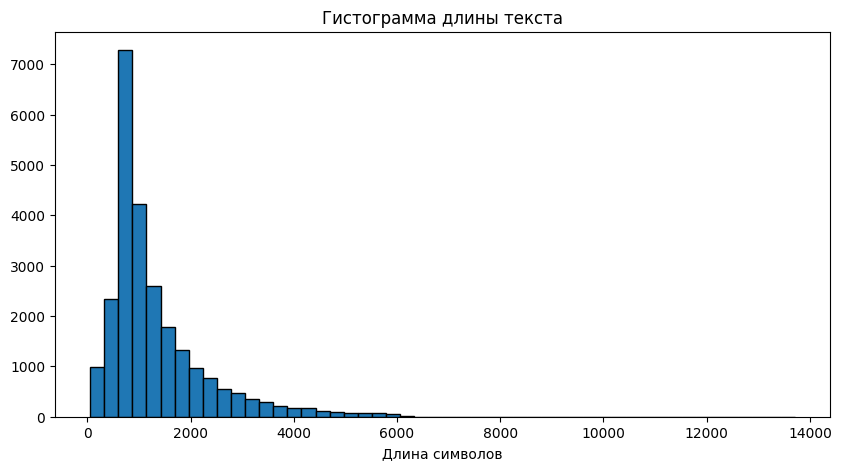

In [5]:
# Выбросы (по длине текста)
if 'text_length' in df.columns:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=df['text_length'])
    plt.title('Распределение длины текста (выбросы)')
    plt.show()
    
    # Гистограмма
    plt.figure(figsize=(10,5))
    plt.hist(df['text_length'], bins=50, edgecolor='black')
    plt.title('Гистограмма длины текста')
    plt.xlabel('Длина символов')
    plt.show()

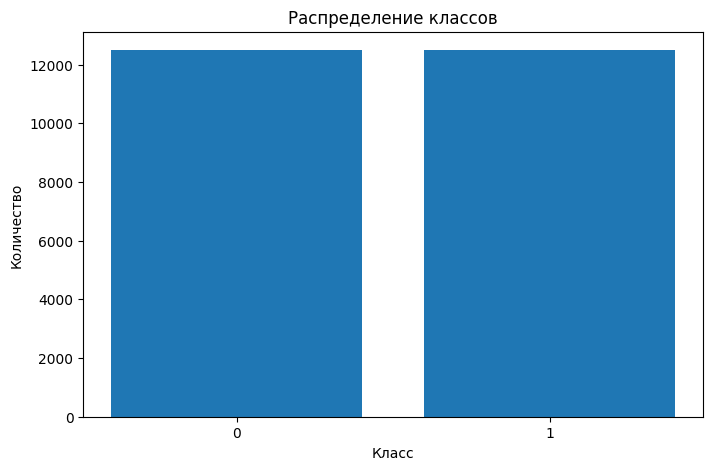

In [6]:
# Дисбаланс классов
if report['imbalance']:
    classes = list(report['imbalance'].keys())
    counts = [report['imbalance'][c]['count'] for c in classes]
    plt.figure(figsize=(8,5))
    plt.bar(classes, counts)
    plt.title('Распределение классов')
    plt.xlabel('Класс')
    plt.ylabel('Количество')
    plt.show()

## Применение стратегий очистки

In [7]:
# Стратегия 1: заполнение пропусков медианой, удаление дубликатов, обрезание выбросов по IQR
strategy1 = {
    'missing': 'median',
    'duplicates': 'drop',
    'outliers': 'clip_iqr'
}
df_clean1 = agent.fix(df, strategy1)
print(f'Размер после очистки (стратегия 1): {df_clean1.shape}')

Размер после очистки (стратегия 1): (24904, 5)


In [8]:
# Стратегия 2: удаление всех строк с пропусками, удаление дубликатов, удаление выбросов
strategy2 = {
    'missing': 'drop',
    'duplicates': 'drop',
    'outliers': 'drop'
}
df_clean2 = agent.fix(df, strategy2)
print(f'Размер после очистки (стратегия 2): {df_clean2.shape}')

Размер после очистки (стратегия 2): (23073, 5)


## Сравнительный отчёт

In [9]:
comparison1 = agent.compare(df, df_clean1)
comparison2 = agent.compare(df, df_clean2)
print("=== Стратегия 1 ===")
display(comparison1)
print("\n=== Стратегия 2 ===")
display(comparison2)

=== Стратегия 1 ===


,Metric,Before,After
0,Missing values (total),0.0,0.000000
1,Duplicate rows,96.0,0.000000
2,Outliers (total),1840.0,0.000000
3,Class imbalance (min ratio),0.5,0.499197



=== Стратегия 2 ===


,Metric,Before,After
0,Missing values (total),0.0,0.000000
1,Duplicate rows,96.0,0.000000
2,Outliers (total),1840.0,924.000000
3,Class imbalance (min ratio),0.5,0.496771


## Обоснование выбора лучшей стратегии

Для моей ML-задачи (классификация текстов) я выбрал **стратегию 1 (медиана + обрезание выбросов)**, потому что:
- Удаление строк с пропусками (стратегия 2) приводит к потере данных, что снижает статистическую мощность.
- Заполнение пропусков медианой сохраняет распределение и не вносит сильных искажений.
- Обрезание выбросов (clip) вместо удаления сохраняет больше данных и предотвращает влияние экстремальных значений на модель.
- Дубликаты удаляются в обеих стратегиях, так как они не несут новой информации.

Таким образом, стратегия 1 обеспечивает наилучший баланс между сохранением данных и качеством чистки.